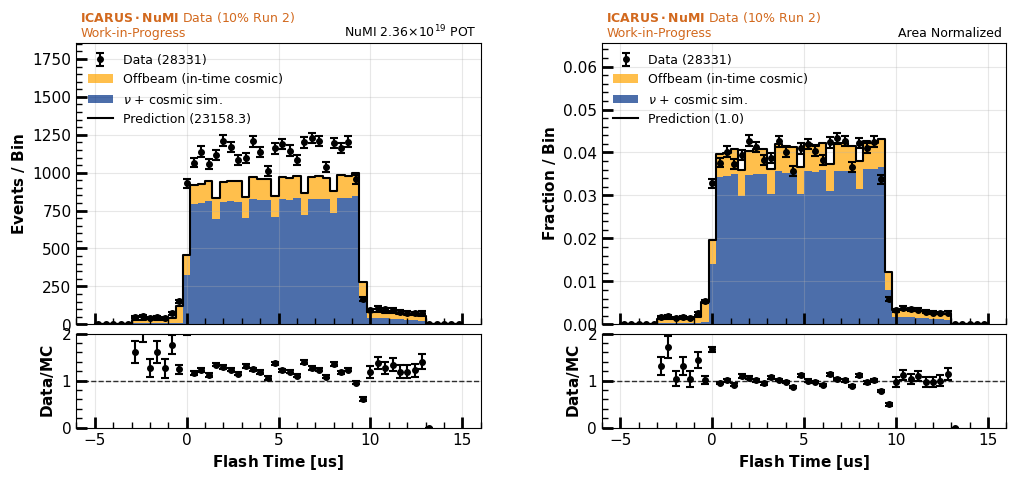

Saved: preselection_flash_time_howard


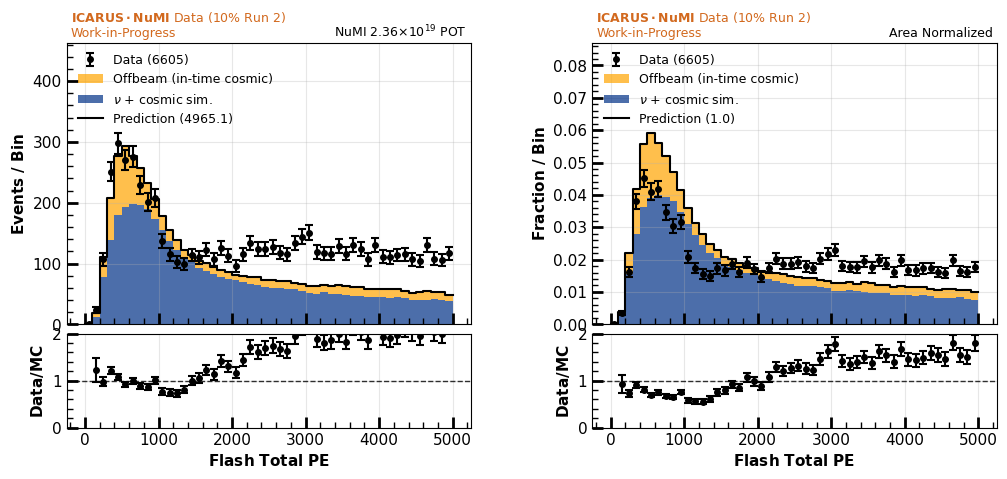

Saved: preselection_flash_total_pe_howard


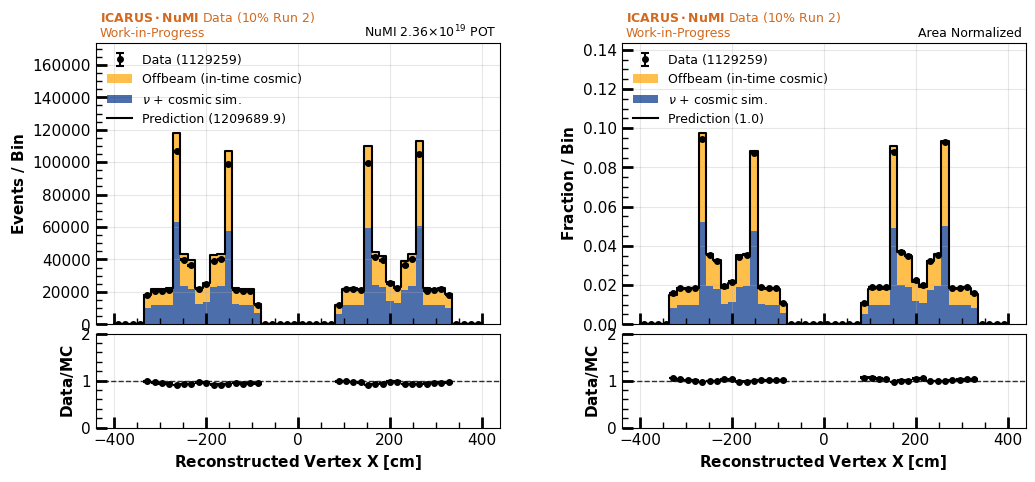

Saved: preselection_vertex_x_howard


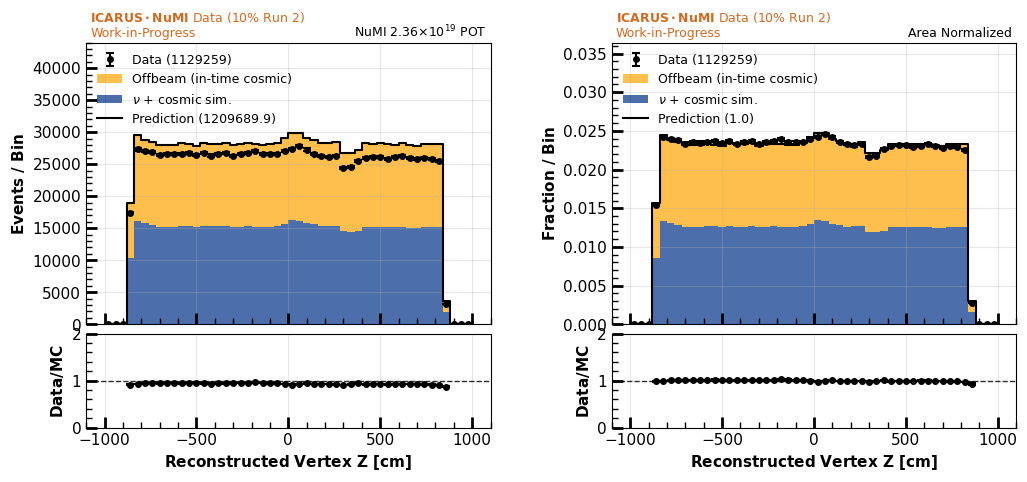

Saved: preselection_vertex_z_howard
Done.


In [5]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os

# ============================================================
# Configuration
# ============================================================
DATA_FILE = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/1muNp0pi_Nge1_uncontained.root"

OUTPUT_DIR = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/ICARUS-NuMI-CC0pi-Selection/spineplot/myAnalysis/1muNp0pi_Nge1_uncontained/preselection"

ONBEAM_POT  = 2.36124e19
NOMINAL_POT = 7.178e20

# ============================================================
# Style helpers
# ============================================================
def apply_tick_style(ax):
    ax.tick_params(axis='both', which='major', labelsize=11, size=8, width=2, direction='in')
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', size=4, width=1, direction='in')
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily('sans-serif')
    ax.yaxis.get_offset_text().set_fontfamily('sans-serif')
    ax.xaxis.get_offset_text().set_fontfamily('sans-serif')

def add_icarus_label(ax, subtitle="Work-in-Progress"):
    yrange = ax.get_ylim()
    xrange = ax.get_xlim()
    usey = yrange[1] + 0.01 * (yrange[1] - yrange[0])
    usex = xrange[0] + 0.01 * (xrange[1] - xrange[0])
    ax.text(usex, usey,
            r'$\bf{ICARUS \cdot NuMI}$ Data (10% Run 2)' + '\n' + subtitle,
            fontsize=9, color="chocolate",
            verticalalignment="bottom", fontfamily="sans-serif")

def add_pot_label(ax, pot_str):
    yrange = ax.get_ylim()
    xrange = ax.get_xlim()
    usey = yrange[1] + 0.01 * (yrange[1] - yrange[0])
    usex_right = xrange[1] - 0.01 * (xrange[1] - xrange[0])
    ax.text(usex_right, usey, pot_str,
            fontsize=9, color="black",
            verticalalignment="bottom", horizontalalignment="right",
            fontfamily="sans-serif")

# ============================================================
# Load data
# ============================================================
f = uproot.open(DATA_FILE)

onbeam_lt   = f["events/onbeam/Livetime"].values().sum()
offbeam_lt  = f["events/offbeam/Livetime"].values().sum()

mc_scale      = ONBEAM_POT / NOMINAL_POT
offbeam_scale = onbeam_lt / offbeam_lt

mc      = f["events/nominal/preselection"].arrays(library="pd")
onbeam  = f["events/onbeam/preselection"].arrays(library="pd")
offbeam = f["events/offbeam/preselection"].arrays(library="pd")

# ============================================================
# Plot: POT normalized (left) and area normalized (right)
# ============================================================
def make_howard_plot(variable, xlabel, bins, range_, output_name):

    fig = plt.figure(figsize=(12, 5))
    gs  = gridspec.GridSpec(2, 2, height_ratios=[3, 1], hspace=0.05, wspace=0.3)

    ax_pot   = fig.add_subplot(gs[0, 0])
    ax_rat1  = fig.add_subplot(gs[1, 0], sharex=ax_pot)
    ax_area  = fig.add_subplot(gs[0, 1])
    ax_rat2  = fig.add_subplot(gs[1, 1], sharex=ax_area)

    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    bin_width   = bins[1:] - bins[:-1]

    # Raw histograms
    mc_h, _      = np.histogram(mc[variable].values,      bins=bins, range=range_)
    offbeam_h, _ = np.histogram(offbeam[variable].values, bins=bins, range=range_)
    onbeam_h, _  = np.histogram(onbeam[variable].values,  bins=bins, range=range_)
    onbeam_err   = np.sqrt(onbeam_h)

    # POT scaled
    mc_pot      = mc_h      * mc_scale
    offbeam_pot = offbeam_h * offbeam_scale
    pred_pot    = mc_pot + offbeam_pot

    # Area normalized (total data = 1)
    total_data   = onbeam_h.sum()
    total_pred   = pred_pot.sum()
    norm_factor  = total_data / total_pred if total_pred > 0 else 1.0
    mc_area      = mc_pot      * norm_factor
    offbeam_area = offbeam_pot * norm_factor
    pred_area    = pred_pot    * norm_factor
    onbeam_area  = onbeam_h    # data stays as counts, will divide by total_data
    onbeam_area_f  = onbeam_h  / total_data
    onbeam_err_area = onbeam_err / total_data
    mc_area_f    = mc_area    / total_data
    offbeam_area_f = offbeam_area / total_data
    pred_area_f  = pred_area  / total_data

    def draw_panel(ax, mc_vals, offbeam_vals, pred_vals,
                   data_vals, data_err, ylabel, pot_str=None, area=False):

        # Stacked bars: MC (blue) + offbeam (orange) on top
        ax.bar(bin_centers, mc_vals,      width=bin_width,
               color="#003087", alpha=0.7, label=r"$\nu$ + cosmic sim.")
        ax.bar(bin_centers, offbeam_vals, width=bin_width, bottom=mc_vals,
               color="orange",  alpha=0.7, label="Offbeam (in-time cosmic)")

        # Prediction line
        ax.step(np.append(bins[:-1], bins[-1]),
                np.append(pred_vals, pred_vals[-1]),
                where='post', color='black', linewidth=1.5,
                label=f"Prediction ({pred_vals.sum():.1f})")

        # Data points
        ax.errorbar(bin_centers, data_vals, yerr=data_err,
                    fmt='o', markersize=4,
                    markerfacecolor="black", markeredgecolor="black",
                    color="black", capsize=3, capthick=1.5, elinewidth=1.5,
                    label=f"Data ({int(data_vals.sum() if not area else total_data)})",
                    zorder=5)

        ax.set_ylabel(ylabel, fontsize=11, fontfamily="sans-serif", fontweight='bold')
        ax.grid(True, alpha=0.3)
        apply_tick_style(ax)
        plt.setp(ax.get_xticklabels(), visible=False)

        # Extend y for legend
        ymax = ax.get_ylim()[1]
        ax.set_ylim(0, ymax * 1.4)

        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles[::-1], labels[::-1], fontsize=9, loc='upper left',
                  framealpha=0.0, edgecolor='none')

        add_icarus_label(ax)
        if pot_str:
            add_pot_label(ax, pot_str)

    def draw_ratio(ax, pred_vals, data_vals, data_err, xlabel):
        with np.errstate(invalid="ignore", divide="ignore"):
            ratio     = np.where(pred_vals > 0, data_vals / pred_vals, np.nan)
            ratio_err = np.where(pred_vals > 0, data_err  / pred_vals, np.nan)

        ax.errorbar(bin_centers, ratio, yerr=ratio_err,
                    fmt='o', markersize=4,
                    markerfacecolor='black', markeredgecolor='black',
                    color='black', capsize=3, capthick=1.5, elinewidth=1.5)
        ax.axhline(1.0, color='black', linestyle='--', linewidth=1.0, alpha=0.8)
        ax.set_ylim(0.0, 2.0)
        ax.set_ylabel(r"$\mathbf{Data/MC}$", fontsize=11)
        ax.set_xlabel(r"$\mathbf{" + xlabel.replace(" ", r"\ ") + "}$", fontsize=11)
        ax.grid(True, alpha=0.3)
        apply_tick_style(ax)

    # POT normalized panel
    draw_panel(ax_pot,
               mc_pot, offbeam_pot, pred_pot,
               onbeam_h, onbeam_err,
               ylabel=r"$\mathbf{Events\ /\ Bin}$",
               pot_str=f"NuMI {ONBEAM_POT/1e19:.2f}" + r"$\times 10^{19}$ POT")
    draw_ratio(ax_rat1, pred_pot, onbeam_h, onbeam_err, xlabel)

    # Area normalized panel
    draw_panel(ax_area,
               mc_area_f, offbeam_area_f, pred_area_f,
               onbeam_area_f, onbeam_err_area,
               ylabel=r"$\mathbf{Fraction\ /\ Bin}$",
               pot_str="Area Normalized",
               area=True)
    draw_ratio(ax_rat2, pred_area_f, onbeam_area_f, onbeam_err_area, xlabel)

    os.makedirs(os.path.join(OUTPUT_DIR, "pdf"),  exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, "jpeg"), exist_ok=True)
    fig.savefig(os.path.join(OUTPUT_DIR, f"pdf/{output_name}.pdf"),   bbox_inches="tight", dpi=300)
    fig.savefig(os.path.join(OUTPUT_DIR, f"jpeg/{output_name}.jpeg"), bbox_inches="tight", dpi=300)
    plt.show()
    plt.close(fig)
    print(f"Saved: {output_name}")

# ============================================================
# Generate plots
# ============================================================
make_howard_plot("reco_flash_time",
                 "Flash Time [us]",
                 np.linspace(-5, 15, 51),
                 (-5, 15),
                 output_name="preselection_flash_time_howard")

make_howard_plot("reco_flash_total_pe",
                 "Flash Total PE",
                 np.linspace(0, 5000, 51),
                 (0, 5000),
                 output_name="preselection_flash_total_pe_howard")

make_howard_plot("reco_vertex_x",
                 "Reconstructed Vertex X [cm]",
                 np.linspace(-400, 400, 51),
                 (-400, 400),
                 output_name="preselection_vertex_x_howard")

make_howard_plot("reco_vertex_z",
                 "Reconstructed Vertex Z [cm]",
                 np.linspace(-1000, 1000, 51),
                 (-1000, 1000),
                 output_name="preselection_vertex_z_howard")

print("Done.")

In [7]:
pre = f["events/nominal/preselection"]
print([b for b in pre.keys() if 'energy' in b.lower() or 'pdg' in b.lower()])

['true_neutrino_energy']
